<a href="https://colab.research.google.com/github/machancejoy-max/colab-git-demo-JOY/blob/main/Assignment14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install fairlearn shap lime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 27.5 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=11d55099d6527ff1a4e164f729258c37a68bad617abc9b99a5f26326f5b8ab39
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from fairlearn.metrics import MetricFrame, selection_rate, true_positive_rate, false_positive_rate

import shap
from lime.lime_tabular import LimeTabularExplainer


In [3]:
# Load Adult dataset from OpenML
adult = fetch_openml(name="adult", version=2, as_frame=True)
df = adult.frame.copy()

print(df.head())
print(df.shape)

   age  workclass  fnlwgt     education  education-num      marital-status  \
0   25    Private  226802          11th              7       Never-married   
1   38    Private   89814       HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm             12  Married-civ-spouse   
3   44    Private  160323  Some-college             10  Married-civ-spouse   
4   18        NaN  103497  Some-college             10       Never-married   

          occupation relationship   race     sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                NaN    Own-child  White  Female             0             0   

   hours-per-week native-country  class  
0       

In [4]:
# Target: income (>50K or <=50K)
y = (df["class"] == ">50K").astype(int)  # 1 = >50K, 0 = <=50K

# Drop target from features
X = df.drop(columns=["class"])

# Sensitive attribute: sex
sensitive_feature = X["sex"]

# For modeling, we'll keep all features except 'fnlwgt' (often dropped)
X = X.drop(columns=["fnlwgt"])


In [5]:
X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
    X, y, sensitive_feature, test_size=0.3, random_state=42, stratify=y
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)


Train size: (34189, 13) Test size: (14653, 13)


In [6]:
# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Preprocessing: scale numeric, one-hot encode categorical
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)

# Full pipeline
clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", log_reg)
])

# Train model
clf.fit(X_train, y_train)



Numeric features: ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [7]:
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8544325394117246

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.94      0.91     11147
           1       0.74      0.60      0.66      3506

    accuracy                           0.85     14653
   macro avg       0.81      0.77      0.78     14653
weighted avg       0.85      0.85      0.85     14653



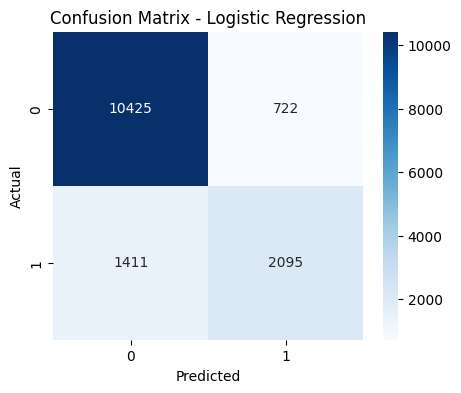

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [9]:
# Define metric functions
metrics = {
    "accuracy": accuracy_score,
    "selection_rate": selection_rate,
    "tpr": true_positive_rate,
    "fpr": false_positive_rate,
}

mf = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=s_test
)

print("Overall metrics:\n", mf.overall)
print("\nBy group (sex):\n", mf.by_group)


Overall metrics:
 accuracy          0.854433
selection_rate    0.192247
tpr               0.597547
fpr               0.064771
dtype: float64

By group (sex):
         accuracy  selection_rate       tpr       fpr
sex                                                 
Female  0.927939        0.075973  0.517179  0.019284
Male    0.817987        0.249898  0.612597  0.093380


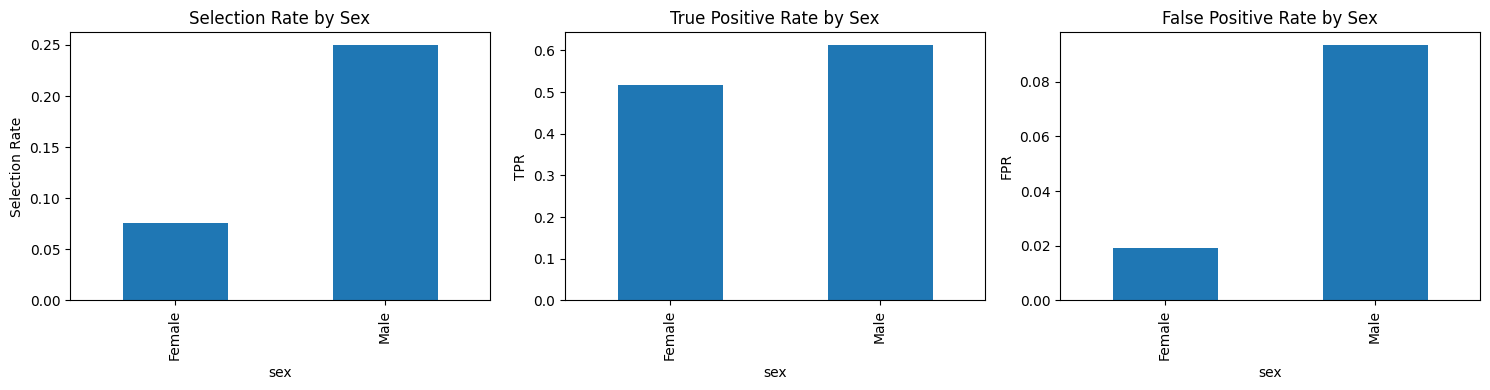

In [10]:
# Bar plots for selection rate, TPR, FPR by sex
fig, axes = plt.subplots(1, 3, figsize=(15,4))

mf.by_group["selection_rate"].plot(kind="bar", ax=axes[0], title="Selection Rate by Sex")
axes[0].set_ylabel("Selection Rate")

mf.by_group["tpr"].plot(kind="bar", ax=axes[1], title="True Positive Rate by Sex")
axes[1].set_ylabel("TPR")

mf.by_group["fpr"].plot(kind="bar", ax=axes[2], title="False Positive Rate by Sex")
axes[2].set_ylabel("FPR")

plt.tight_layout()
plt.show()


In [11]:
# Get preprocessed training data (for SHAP)
X_train_transformed = clf.named_steps["preprocess"].transform(X_train)
X_test_transformed = clf.named_steps["preprocess"].transform(X_test)

# Underlying model
model = clf.named_steps["model"]


/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


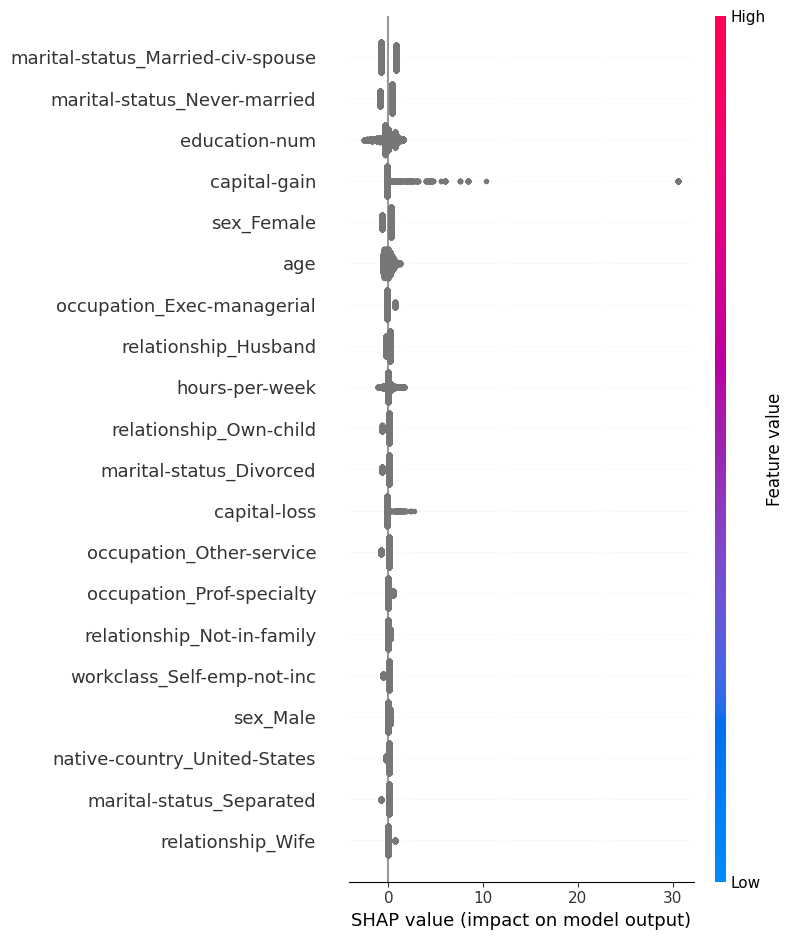

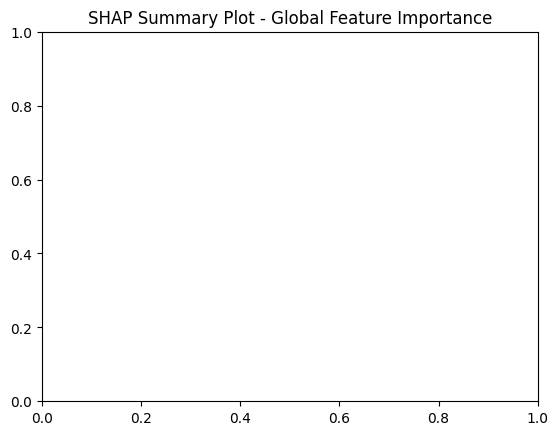

In [12]:
# Create SHAP explainer (updated syntax)
explainer = shap.LinearExplainer(
    model,
    X_train_transformed,
    feature_perturbation="interventional"
)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_transformed)

# Get feature names
ohe = clf.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)
feature_names = np.concatenate([numeric_features, cat_feature_names])

# Summary plot
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)
plt.title("SHAP Summary Plot - Global Feature Importance")
plt.show()


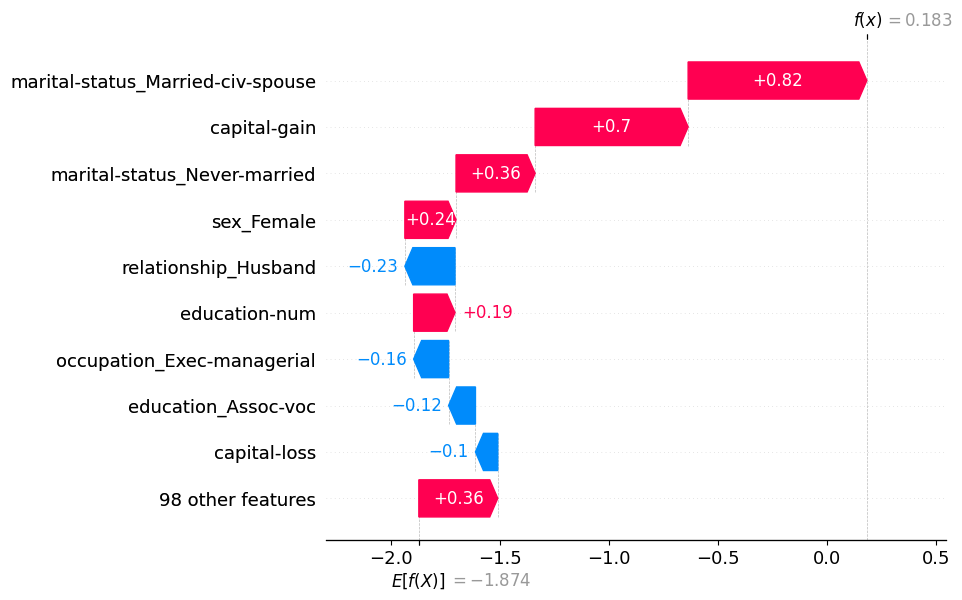

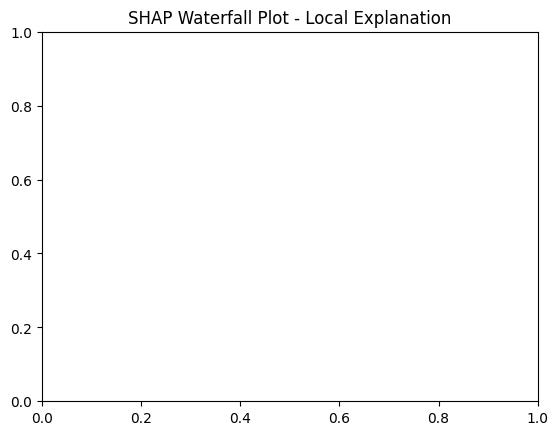

In [13]:
# Pick one instance
idx = 0
instance = X_test_transformed[idx]

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[idx],
    feature_names=feature_names,
    max_display=10
)
plt.title("SHAP Waterfall Plot - Local Explanation")
plt.show()


In [14]:
# LIME works on numeric data; we use transformed features
explainer_lime = LimeTabularExplainer(
    training_data=X_train_transformed,
    feature_names=feature_names,
    class_names=["<=50K", ">50K"],
    discretize_continuous=True
)

In [15]:
from lime.lime_tabular import LimeTabularExplainer

In [16]:

# Defines LimeModelWrapper and verifies it exists


class LimeModelWrapper:
    def __init__(self, model):
        self.model = model

    def predict_proba(self, X):
        return self.model.predict_proba(X)

# Sanity check
print("LimeModelWrapper is defined:", 'LimeModelWrapper' in globals())


LimeModelWrapper is defined: True


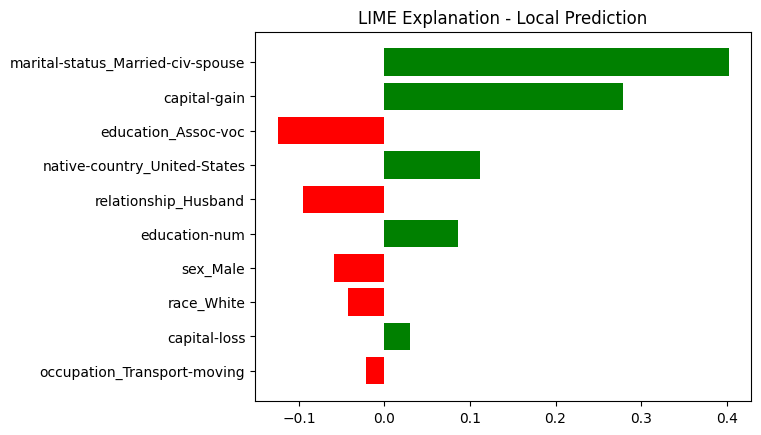

In [17]:
# Wrap the model
wrapped_model = LimeModelWrapper(model)

# Choose an instance
i = 0
instance = X_test_transformed[i]

# Generate explanation
exp = explainer_lime.explain_instance(
    data_row=instance,
    predict_fn=wrapped_model.predict_proba,
    num_features=10
)

# Plot
fig = exp.as_pyplot_figure()
plt.title("LIME Explanation - Local Prediction")
plt.show()
